# Uncovering Low-Dimensional Structure in Abalone Morphology via Principal Component Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv('abalone_data.csv')
# Separate numeric features and target
numeric_cols = ['Length', 'Diameter', 'Height', 'Whole_weight',
'Shucked_weight', 'Viscera_weight', 'Shell_weight']
X_numeric = df[numeric_cols]
sex = df['Sex']
rings = df['Rings']
print(f"Samples: {len(df)}, Numeric features: {len(numeric_cols)}")
print(f"Sex distribution: {df['Sex'].value_counts().to_dict()}")

Samples: 4177, Numeric features: 7
Sex distribution: {'M': 1528, 'I': 1342, 'F': 1307}


## Summary Statistics

In [2]:
# Compute summary statistics
summary_stats = X_numeric.describe().T

# Add median explicitly (describe() already has mean/std/min/max)
summary_stats["median"] = X_numeric.median()

# Reorder columns for readability
summary_stats = summary_stats[
    ["count", "mean", "median", "std", "min", "25%", "75%", "max"]
]

print(summary_stats)

                 count      mean  median       std     min     25%    75%  \
Length          4177.0  0.523992  0.5450  0.120093  0.0750  0.4500  0.615   
Diameter        4177.0  0.407881  0.4250  0.099240  0.0550  0.3500  0.480   
Height          4177.0  0.139516  0.1400  0.041827  0.0000  0.1150  0.165   
Whole_weight    4177.0  0.828742  0.7995  0.490389  0.0020  0.4415  1.153   
Shucked_weight  4177.0  0.359367  0.3360  0.221963  0.0010  0.1860  0.502   
Viscera_weight  4177.0  0.180594  0.1710  0.109614  0.0005  0.0935  0.253   
Shell_weight    4177.0  0.238831  0.2340  0.139203  0.0015  0.1300  0.329   

                   max  
Length          0.8150  
Diameter        0.6500  
Height          1.1300  
Whole_weight    2.8255  
Shucked_weight  1.4880  
Viscera_weight  0.7600  
Shell_weight    1.0050  


## Boxplot

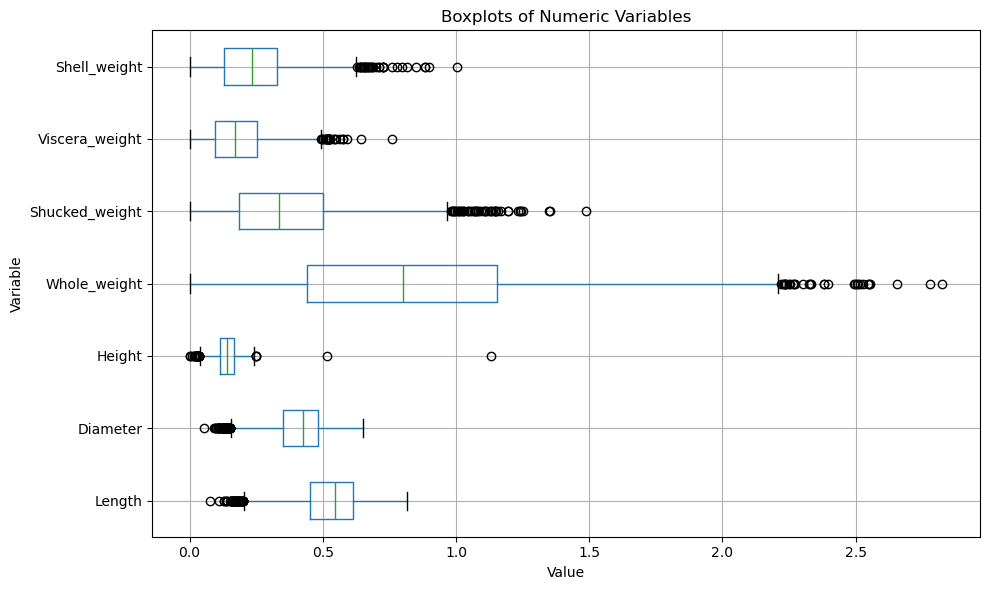

In [3]:
plt.figure(figsize=(10, 6))

X_numeric.boxplot(vert=False)

plt.title("Boxplots of Numeric Variables")
plt.xlabel("Value")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

## Correlation Heatmap

In [4]:
# Compute correlation matrix
corr_matrix = X_numeric.corr()

print(corr_matrix)

                  Length  Diameter    Height  Whole_weight  Shucked_weight  \
Length          1.000000  0.986812  0.827554      0.925261        0.897914   
Diameter        0.986812  1.000000  0.833684      0.925452        0.893162   
Height          0.827554  0.833684  1.000000      0.819221        0.774972   
Whole_weight    0.925261  0.925452  0.819221      1.000000        0.969405   
Shucked_weight  0.897914  0.893162  0.774972      0.969405        1.000000   
Viscera_weight  0.903018  0.899724  0.798319      0.966375        0.931961   
Shell_weight    0.897706  0.905330  0.817338      0.955355        0.882617   

                Viscera_weight  Shell_weight  
Length                0.903018      0.897706  
Diameter              0.899724      0.905330  
Height                0.798319      0.817338  
Whole_weight          0.966375      0.955355  
Shucked_weight        0.931961      0.882617  
Viscera_weight        1.000000      0.907656  
Shell_weight          0.907656      1.000000  

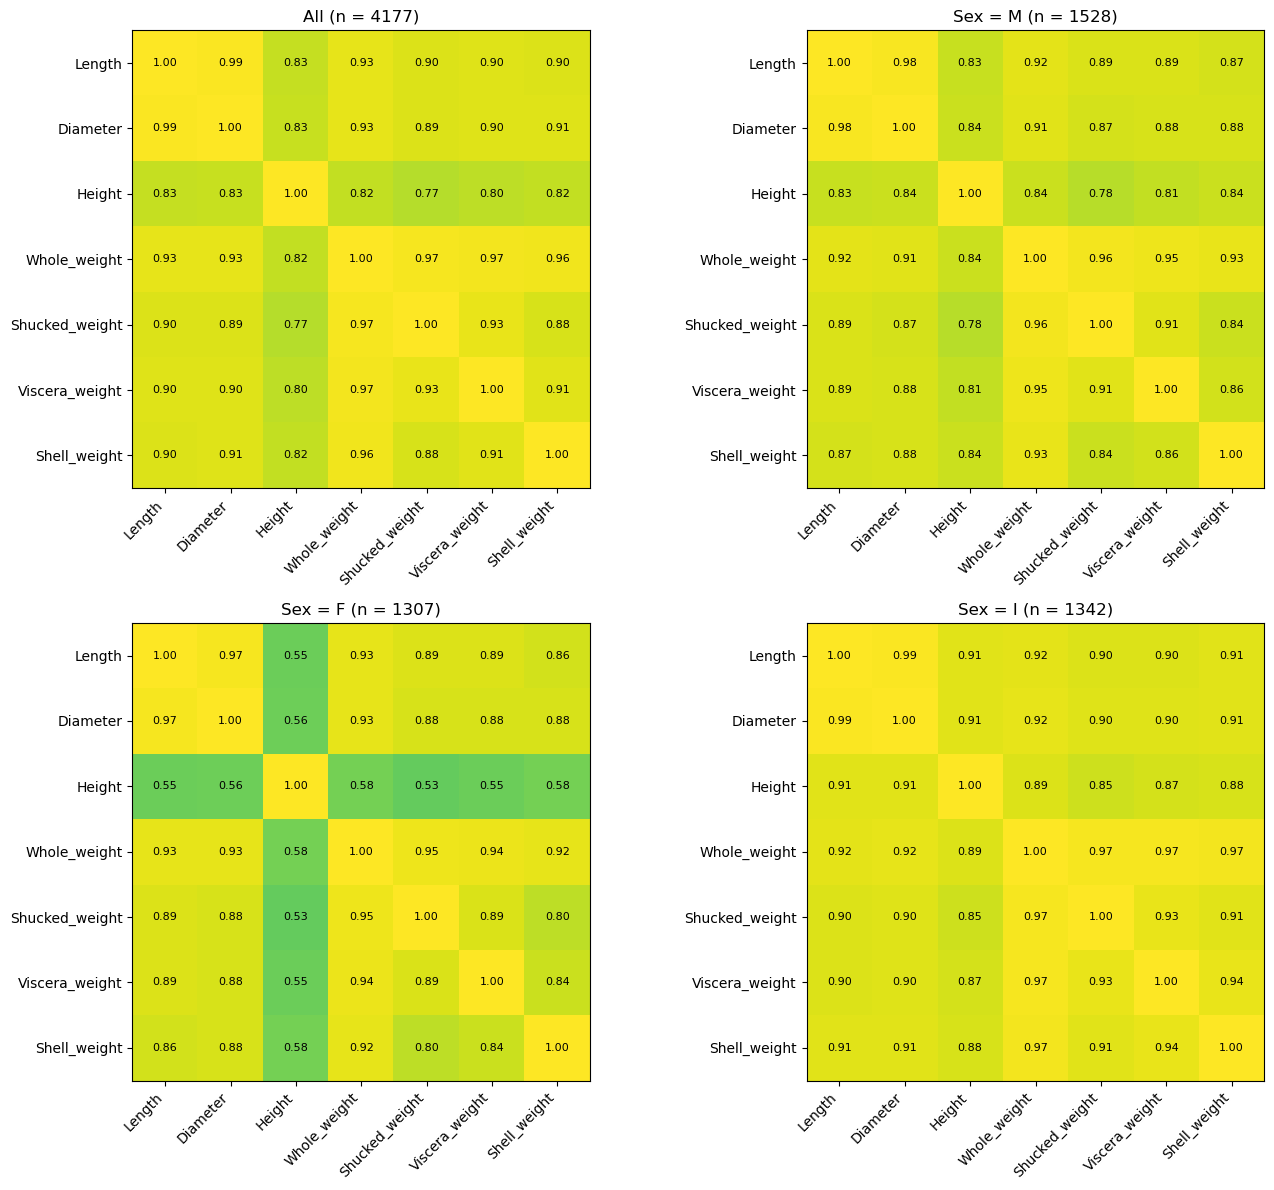

In [5]:
groups = [None, "M", "F", "I"]   # None = all data
titles = [
    "All",
    "Sex = M",
    "Sex = F",
    "Sex = I"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, g, title in zip(axes.flat, groups, titles):

    if g is None:
        sub = df
    else:
        sub = df[df["Sex"] == g]

    corr = sub[numeric_cols].corr()

    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="viridis")

    ax.set_xticks(np.arange(len(numeric_cols)))
    ax.set_yticks(np.arange(len(numeric_cols)))
    ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
    ax.set_yticklabels(numeric_cols)

    ax.set_title(f"{title} (n = {len(sub)})")

    # numbers
    for i in range(len(numeric_cols)):
        for j in range(len(numeric_cols)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}",
                    ha="center", va="center", fontsize=8)



plt.tight_layout()
plt.savefig("heatmap_2x2.png", dpi=300, bbox_inches="tight")
plt.show()

## PCA

In [6]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_numeric)

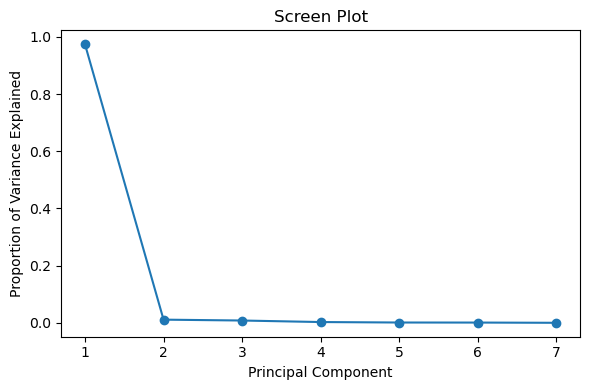

In [7]:
import numpy as np
import matplotlib.pyplot as plt

explained_var_ratio = pca.explained_variance_ratio_

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(explained_var_ratio) + 1),
         explained_var_ratio,
         marker='o')

plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.title("Screen Plot")
plt.xticks(range(1, len(explained_var_ratio) + 1))
plt.tight_layout()
plt.show()

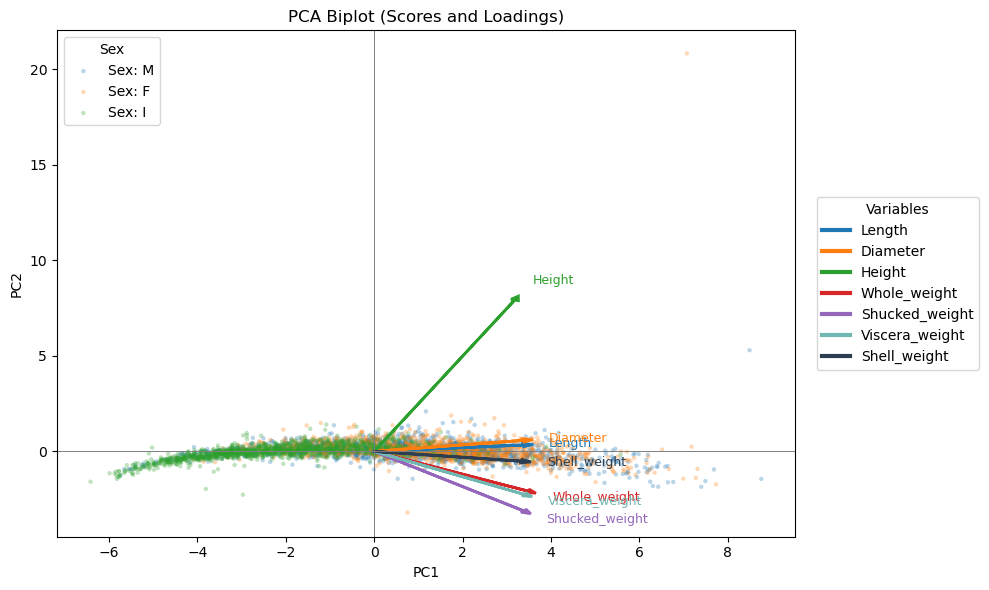

In [8]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

X = df[numeric_cols].values
y = df["Sex"]

# standardize
X_std = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
scores = pca.fit_transform(X_std)

# loadings
loadings = pca.components_.T

plt.figure(figsize=(10, 6))

# -----------------------
# Score plot (Sex)
# -----------------------
sex_colors = {"M": "tab:blue", "F": "tab:orange", "I": "tab:green"}

for g in ["M", "F", "I"]:
    mask = (y == g)
    plt.scatter(
        scores[mask, 0],
        scores[mask, 1],
        alpha=0.30,
        s=10,
        label=f"Sex: {g}",
        color=sex_colors[g],
        edgecolors="none"
    )

# -----------------------
# Variable colors
# -----------------------
var_colors = {
    "Length": "#1f77b4",
    "Diameter": "#ff7f0e",
    "Height": "#2ca02c",
    "Whole_weight": "#d62728",
    "Shucked_weight": "#9467bd",
    "Viscera_weight": "#72B7B2",
    "Shell_weight": "#2c3e50"
}

scale = np.max(np.abs(scores)) * 0.45

# -----------------------
# Loading arrows
# -----------------------
for i, var in enumerate(numeric_cols):
    x = loadings[i, 0] * scale
    yv = loadings[i, 1] * scale

    color = var_colors[var]

    plt.arrow(
        0, 0, x, yv,
        color=color,
        linewidth=2,
        head_width=0.18,
        head_length=0.22,
        length_includes_head=True
    )

    plt.text(
        x * 1.10,
        yv * 1.10,
        var,
        fontsize=9,
        color=color,
        ha="left",
        va="center"
    )

# -----------------------
# Axis
# -----------------------
plt.axhline(0, color="grey", lw=0.7)
plt.axvline(0, color="grey", lw=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Biplot (Scores and Loadings)")

# -----------------------
# Create separate legend for variables
# -----------------------
var_legend_elements = [
    Line2D([0], [0], color=var_colors[var], lw=3, label=var)
    for var in numeric_cols
]

# First legend: Sex
legend1 = plt.legend(title="Sex", loc="upper left")
plt.gca().add_artist(legend1)

# Second legend: Variables
plt.legend(
    handles=var_legend_elements,
    title="Variables",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.show()

## Inferences on PCA

In [9]:
# Standardize (mean=0, std=1) -> correlation-PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

# Observed PCA
pca_obs = PCA().fit(X_scaled)
obs_eigvals = pca_obs.explained_variance_               # eigenvalues of correlation matrix
obs_evr = pca_obs.explained_variance_ratio_             # explained variance ratio
p = X_scaled.shape[1]

print("Observed explained variance ratio:", np.round(obs_evr, 4))
print("Observed eigenvalues:", np.round(obs_eigvals, 4))

Observed explained variance ratio: [0.9079 0.0399 0.0239 0.0163 0.0092 0.0018 0.001 ]
Observed eigenvalues: [6.3566 0.2795 0.1674 0.1141 0.0647 0.0127 0.0067]


### Permutation Test

In [10]:
def permute_columns_independently(X, rng):
    """
    X: (n, p) numpy array
    Returns X_perm where each column is independently permuted across rows.
    Preserves each variable's marginal distribution but breaks cross-variable correlations.
    """
    X_perm = X.copy()
    n, p = X_perm.shape
    for j in range(p):
        rng.shuffle(X_perm[:, j])
    return X_perm

def permutation_pca_null(X_scaled, n_perm=1000, seed=42):
    rng = np.random.default_rng(seed)
    p = X_scaled.shape[1]

    null_eigvals = np.zeros((n_perm, p))
    null_evr = np.zeros((n_perm, p))

    for b in range(n_perm):
        Xp = permute_columns_independently(X_scaled, rng)
        pca_b = PCA().fit(Xp)
        null_eigvals[b, :] = pca_b.explained_variance_
        null_evr[b, :] = pca_b.explained_variance_ratio_

    return null_eigvals, null_evr

n_perm = 1000
null_eigvals, null_evr = permutation_pca_null(X_scaled, n_perm=n_perm, seed=123)

print("Permutation null generated:", null_eigvals.shape)

Permutation null generated: (1000, 7)


In [11]:
def right_tail_pvalues(null_samples, observed):
    """
    null_samples: (B, p)
    observed: (p,)
    """
    B = null_samples.shape[0]
    pvals = (np.sum(null_samples >= observed, axis=0) + 1) / (B + 1)
    return pvals

pvals_eig = right_tail_pvalues(null_eigvals, obs_eigvals)
pvals_evr = right_tail_pvalues(null_evr, obs_evr)

results_perm = pd.DataFrame({
    "PC": [f"PC{k}" for k in range(1, p+1)],
    "obs_eigenvalue": obs_eigvals,
    "pval_eigenvalue": pvals_eig,
    "obs_EVR": obs_evr,
    "pval_EVR": pvals_evr
})

print(results_perm)

    PC  obs_eigenvalue  pval_eigenvalue   obs_EVR  pval_EVR
0  PC1        6.356634         0.000999  0.907873  0.000999
1  PC2        0.279499         1.000000  0.039919  1.000000
2  PC3        0.167385         1.000000  0.023906  1.000000
3  PC4        0.114099         1.000000  0.016296  1.000000
4  PC5        0.064669         1.000000  0.009236  1.000000
5  PC6        0.012731         1.000000  0.001818  1.000000
6  PC7        0.006659         1.000000  0.000951  1.000000


### Bootstrap CIs

In [12]:
def bootstrap_pca(X_scaled, n_boot=1000, seed=42, cum_threshold=0.80):
    rng = np.random.default_rng(seed)
    n, p = X_scaled.shape

    boot_evr = np.zeros((n_boot, p))
    boot_eigvals = np.zeros((n_boot, p))
    boot_k80 = np.zeros(n_boot, dtype=int)

    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)  # resample rows with replacement
        Xb = X_scaled[idx, :]
        pca_b = PCA().fit(Xb)

        evr_b = pca_b.explained_variance_ratio_
        boot_evr[b, :] = evr_b
        boot_eigvals[b, :] = pca_b.explained_variance_

        k80 = np.searchsorted(np.cumsum(evr_b), cum_threshold) + 1  # +1 because PCs are 1-indexed
        boot_k80[b] = k80

    return boot_evr, boot_eigvals, boot_k80

n_boot = 1000
boot_evr, boot_eigvals, boot_k80 = bootstrap_pca(X_scaled, n_boot=n_boot, seed=456, cum_threshold=0.80)

print("Bootstrap done:", boot_evr.shape, boot_k80[:10])

Bootstrap done: (1000, 7) [1 1 1 1 1 1 1 1 1 1]


In [13]:
def ci_from_samples(samples, alpha=0.05):
    lower = np.quantile(samples, alpha/2, axis=0)
    upper = np.quantile(samples, 1 - alpha/2, axis=0)
    return lower, upper

evr_ci_low, evr_ci_high = ci_from_samples(boot_evr, alpha=0.05)

results_boot = pd.DataFrame({
    "PC": [f"PC{k}" for k in range(1, p+1)],
    "obs_EVR": obs_evr,
    "boot_CI_low": evr_ci_low,
    "boot_CI_high": evr_ci_high
})

print(results_boot)

    PC   obs_EVR  boot_CI_low  boot_CI_high
0  PC1  0.907873     0.874293      0.926668
1  PC2  0.039919     0.028914      0.072793
2  PC3  0.023906     0.018866      0.025287
3  PC4  0.016296     0.012481      0.017545
4  PC5  0.009236     0.008459      0.009864
5  PC6  0.001818     0.001607      0.002110
6  PC7  0.000951     0.000798      0.001133


In [14]:
k80_low, k80_high = np.quantile(boot_k80, [0.025, 0.975])

print(f"Observed k to reach 80% variance: {np.searchsorted(np.cumsum(obs_evr), 0.80) + 1}")
print(f"Bootstrap 95% CI for k80: [{k80_low:.0f}, {k80_high:.0f}]")

Observed k to reach 80% variance: 1
Bootstrap 95% CI for k80: [1, 1]


# Allometric Scaling and Age Determination in Abalone: A Data-Driven Investigation

## Data Modeling

### 1. Split the dataset into 80% training set and 20% testing set.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import statsmodels.api as sm

# 0) Load data
# -----------------------------
df = pd.read_csv("abalone_data.csv")

numeric_cols = [
    "Length", "Diameter", "Height",
    "Whole_weight", "Shucked_weight", "Viscera_weight", "Shell_weight"
]
target_col = "Rings"

RANDOM_STATE = 42

X = df[numeric_cols].copy()
y = df[target_col].astype(int).copy()  # Rings is a count variable

# 1) Train/Test split (80/20)
# Note: You can stratify by Sex to keep the same M/F/I proportions in train/test.
# If you don't care, remove stratify=...
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["Sex"]  # keep Sex proportions similar (optional but nice)
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (3341, 7) Test size: (836, 7)


### 2. Check the overdispersion

In [16]:
# We check dispersion only on the TRAINING set
y_train_values = y_train.values

mean_y = np.mean(y_train_values)
var_y = np.var(y_train_values, ddof=1)  # sample variance

dispersion_ratio = var_y / mean_y

overdisp_table = pd.DataFrame({
    "Sample_Size": [len(y_train_values)],
    "Mean_of_Rings": [mean_y],
    "Variance_of_Rings": [var_y],
    "Variance/Mean_Ratio": [dispersion_ratio]
})

display(overdisp_table)

,Sample_Size,Mean_of_Rings,Variance_of_Rings,Variance/Mean_Ratio
0,3341,9.936247,10.321982,1.038821


### 3. Modeling by using negative binomial regression

In [38]:
# ----------------------------
# 1) Standardize original predictors
# ----------------------------
scaler_orig = StandardScaler()
X_train_std = scaler_orig.fit_transform(X_train)
X_test_std  = scaler_orig.transform(X_test)

X_train_std_df = pd.DataFrame(X_train_std, columns=numeric_cols, index=X_train.index)
X_test_std_df  = pd.DataFrame(X_test_std,  columns=numeric_cols, index=X_test.index)

# Add intercept
X_train_std_df_const = sm.add_constant(X_train_std_df, has_constant="add")
X_test_std_df_const  = sm.add_constant(X_test_std_df,  has_constant="add")

# ----------------------------
# 2) Estimate alpha on training set (original predictors)
#    Use MLE NB ONLY to get alpha_hat
# ----------------------------
nb_alpha_model_orig = sm.NegativeBinomial(y_train, X_train_std_df_const)
nb_alpha_res_orig = nb_alpha_model_orig.fit(disp=False)

alpha_hat_orig = float(nb_alpha_res_orig.params["alpha"])
print(f"[Alpha estimate | Original] alpha_hat = {alpha_hat_orig:.6g}")

# ----------------------------
# 3) NB regression with fixed alpha (GLM)
# ----------------------------
nb_model_orig = sm.GLM(
    y_train,
    X_train_std_df_const,
    family=sm.families.NegativeBinomial(alpha=alpha_hat_orig)
)
nb_res_orig = nb_model_orig.fit()

# Predict on test set
mu_test_orig = nb_res_orig.predict(X_test_std_df_const)

[Alpha estimate | Original] alpha_hat = 2.81166e-08


/opt/conda/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [39]:
# ----------------------------
# 4) PCA on training set only (avoid leakage)
# ----------------------------
scaler_pca = StandardScaler()
X_train_pca_std = scaler_pca.fit_transform(X_train)
X_test_pca_std  = scaler_pca.transform(X_test)

pca2 = PCA(n_components=2, random_state=42)
Z_train = pca2.fit_transform(X_train_pca_std)
Z_test  = pca2.transform(X_test_pca_std)

Z_train_df = pd.DataFrame(Z_train, columns=["PC1", "PC2"], index=X_train.index)
Z_test_df  = pd.DataFrame(Z_test,  columns=["PC1", "PC2"], index=X_test.index)

Z_train_df_const = sm.add_constant(Z_train_df, has_constant="add")
Z_test_df_const  = sm.add_constant(Z_test_df,  has_constant="add")

# ----------------------------
# 5) Estimate alpha for PCA model (train only)
# ----------------------------
nb_alpha_model_pca = sm.NegativeBinomial(y_train, Z_train_df_const)
nb_alpha_res_pca = nb_alpha_model_pca.fit(disp=False)

alpha_hat_pca = float(nb_alpha_res_pca.params["alpha"])
print(f"[Alpha estimate | PCA] alpha_hat = {alpha_hat_pca:.6g}")

# ----------------------------
# 6) NB regression with fixed alpha (GLM) for PCA model
# ----------------------------
nb_model_pca = sm.GLM(
    y_train,
    Z_train_df_const,
    family=sm.families.NegativeBinomial(alpha=alpha_hat_pca)
)
nb_res_pca = nb_model_pca.fit()

mu_test_pca = nb_res_pca.predict(Z_test_df_const)

[Alpha estimate | PCA] alpha_hat = 5.88916e-07


In [40]:
# ----------------------------
# 7) Test Deviance Function (your Poisson-style deviance)
# ----------------------------
def nb_deviance(y_true, mu):
    y_true = np.asarray(y_true, dtype=float)
    mu = np.asarray(mu, dtype=float)
    mu = np.clip(mu, 1e-12, None)

    term = np.zeros_like(y_true)
    mask = y_true > 0
    term[mask] = y_true[mask] * np.log(y_true[mask] / mu[mask])
    D = 2 * np.sum(term - (y_true - mu))
    return D

test_dev_orig = nb_deviance(y_test.values, mu_test_orig)
test_dev_pca  = nb_deviance(y_test.values, mu_test_pca)

# ----------------------------
# 8) Comparison Table
# ----------------------------
comparison_table = pd.DataFrame([
    {
        "Model": "NB (Original variables) [alpha estimated then fixed]",
        "alpha_hat": alpha_hat_orig,
        "AIC": nb_res_orig.aic,
        "Test_Deviance": test_dev_orig
    },
    {
        "Model": "NB (PC1 + PC2) [alpha estimated then fixed]",
        "alpha_hat": alpha_hat_pca,
        "AIC": nb_res_pca.aic,
        "Test_Deviance": test_dev_pca
    }
])

display(comparison_table)

# Optional: show regression summaries
print("\n--- GLM NB (Original) summary ---")
print(nb_res_orig.summary())

print("\n--- GLM NB (PC1 + PC2) summary ---")
print(nb_res_pca.summary())

,Model,alpha_hat,AIC,Test_Deviance
0,NB (Original variables) [alpha estimated then ...,2.811658e-08,15218.045982,402.634765
1,NB (PC1 + PC2) [alpha estimated then fixed],5.889160e-07,15810.670332,531.360430



--- GLM NB (Original) summary ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Rings   No. Observations:                 3341
Model:                            GLM   Df Residuals:                     3333
Model Family:        NegativeBinomial   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7601.0
Date:                Sun, 22 Feb 2026   Deviance:                       1494.5
Time:                        21:36:46   Pearson chi2:                 1.57e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.4152
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const    

## Original model is better in this case. Because it has lower AIC, lower deviance and higher R square.

In [41]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df["Variable"] = X_train_std_df.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_train_std_df.values, i)
    for i in range(X_train_std_df.shape[1])
]

print(vif_df)

         Variable         VIF
0          Length   40.274134
1        Diameter   41.664786
2          Height    3.345480
3    Whole_weight  109.196158
4  Shucked_weight   28.448990
5  Viscera_weight   17.043059
6    Shell_weight   21.123415


## To ensure the interpretability of the model, we try to eliminate Shucked_weight, Viscera_weight, and Shell_weight.

In [42]:
reduced_cols = [
    "Length",
    "Diameter",
    "Height",
    "Whole_weight"
]

X_reduced = df[reduced_cols].copy()
y = df[target_col].astype(int).copy()

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["Sex"]
)

scaler_r = StandardScaler()

X_train_r_std = scaler_r.fit_transform(X_train_r)
X_test_r_std  = scaler_r.transform(X_test_r)

X_train_r_df = pd.DataFrame(X_train_r_std, columns=reduced_cols, index=X_train_r.index)
X_test_r_df  = pd.DataFrame(X_test_r_std,  columns=reduced_cols, index=X_test_r.index)

X_train_r_const = sm.add_constant(X_train_r_df)
X_test_r_const  = sm.add_constant(X_test_r_df)

nb_alpha_model_r = sm.NegativeBinomial(y_train_r, X_train_r_const)
nb_alpha_res_r = nb_alpha_model_r.fit(disp=False)

alpha_hat_r = float(nb_alpha_res_r.params["alpha"])
print("Estimated alpha (Reduced):", alpha_hat_r)



Estimated alpha (Reduced): 2.0074407272340914e-08
                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Rings   No. Observations:                 3341
Model:                            GLM   Df Residuals:                     3336
Model Family:        NegativeBinomial   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7867.4
Date:                Sun, 22 Feb 2026   Deviance:                       2027.2
Time:                        21:48:29   Pearson chi2:                 2.22e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3141
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

/opt/conda/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/opt/conda/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [43]:
vif_df_r = pd.DataFrame()
vif_df_r["Variable"] = X_train_r_df.columns
vif_df_r["VIF"] = [
    variance_inflation_factor(X_train_r_df.values, i)
    for i in range(X_train_r_df.shape[1])
]

print(vif_df_r)

       Variable        VIF
0        Length  39.285171
1      Diameter  40.456574
2        Height   3.256962
3  Whole_weight   7.560225


## The VIFs look much better, but can we improve something? We can consider the Area=length * diamter, so that we can have smaller VIFs.

In [45]:
df["Area"] = df["Length"] * df["Diameter"]
final_cols = [
    "Area",   
    "Height",
    "Whole_weight"
]

X_new = df[final_cols].copy()
y = df["Rings"].astype(int).copy()

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["Sex"]
)

scaler_new = StandardScaler()

X_train_new_std = scaler_new.fit_transform(X_train_new)
X_test_new_std  = scaler_new.transform(X_test_new)

X_train_new_df = pd.DataFrame(X_train_new_std, columns=final_cols, index=X_train_new.index)
X_test_new_df  = pd.DataFrame(X_test_new_std,  columns=final_cols, index=X_test_new.index)

X_train_new_const = sm.add_constant(X_train_new_df)
X_test_new_const  = sm.add_constant(X_test_new_df)

nb_alpha_model_new = sm.NegativeBinomial(y_train_new, X_train_new_const)
nb_alpha_res_new = nb_alpha_model_new.fit(disp=False)

alpha_hat_new = float(nb_alpha_res_new.params["alpha"])
print("Estimated alpha (Area model):", alpha_hat_new)

nb_model_new = sm.GLM(
    y_train_new,
    X_train_new_const,
    family=sm.families.NegativeBinomial(alpha=alpha_hat_new)
)

nb_res_new = nb_model_new.fit()

mu_test_new = nb_res_new.predict(X_test_new_const)

print(nb_res_new.summary())

Estimated alpha (Area model): 2.2403274734784965e-08
                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Rings   No. Observations:                 3341
Model:                            GLM   Df Residuals:                     3337
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7927.1
Date:                Sun, 22 Feb 2026   Deviance:                       2146.7
Time:                        21:56:13   Pearson chi2:                 2.34e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2891
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------

/opt/conda/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


In [46]:
vif_df_new = pd.DataFrame()
vif_df_new["Variable"] = X_train_new_df.columns
vif_df_new["VIF"] = [
    variance_inflation_factor(X_train_new_df.values, i)
    for i in range(X_train_new_df.shape[1])
]

print(vif_df_new)

       Variable        VIF
0          Area  13.717526
1        Height   3.044505
2  Whole_weight  13.248998


## Can we do better? What if we remove the parameter "length"?

In [47]:
cols_no_length = [
    "Diameter",
    "Height",
    "Whole_weight"
]

X_nl = df[cols_no_length].copy()
y = df["Rings"].astype(int).copy()

X_train_nl, X_test_nl, y_train_nl, y_test_nl = train_test_split(
    X_nl,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["Sex"]
)

scaler_nl = StandardScaler()

X_train_nl_std = scaler_nl.fit_transform(X_train_nl)
X_test_nl_std  = scaler_nl.transform(X_test_nl)

X_train_nl_df = pd.DataFrame(X_train_nl_std, columns=cols_no_length, index=X_train_nl.index)
X_test_nl_df  = pd.DataFrame(X_test_nl_std,  columns=cols_no_length, index=X_test_nl.index)

X_train_nl_const = sm.add_constant(X_train_nl_df)
X_test_nl_const  = sm.add_constant(X_test_nl_df)

nb_alpha_model_nl = sm.NegativeBinomial(y_train_nl, X_train_nl_const)
nb_alpha_res_nl = nb_alpha_model_nl.fit(disp=False)

alpha_hat_nl = float(nb_alpha_res_nl.params["alpha"])
print("Estimated alpha (No Length):", alpha_hat_nl)

nb_model_nl = sm.GLM(
    y_train_nl,
    X_train_nl_const,
    family=sm.families.NegativeBinomial(alpha=alpha_hat_nl)
)

nb_res_nl = nb_model_nl.fit()

mu_test_nl = nb_res_nl.predict(X_test_nl_const)

print(nb_res_nl.summary())

Estimated alpha (No Length): 2.4867203865982135e-06
                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Rings   No. Observations:                 3341
Model:                            GLM   Df Residuals:                     3337
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7871.7
Date:                Sun, 22 Feb 2026   Deviance:                       2035.8
Time:                        21:59:32   Pearson chi2:                 2.23e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3123
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

In [48]:
vif_df_nl = pd.DataFrame()
vif_df_nl["Variable"] = X_train_nl_df.columns
vif_df_nl["VIF"] = [
    variance_inflation_factor(X_train_nl_df.values, i)
    for i in range(X_train_nl_df.shape[1])
]

print(vif_df_nl)

       Variable       VIF
0      Diameter  7.921521
1        Height  3.256919
2  Whole_weight  7.296831


## Testing

In [51]:
def poisson_style_deviance(y_true, mu):
    y_true = np.asarray(y_true, dtype=float)
    mu = np.asarray(mu, dtype=float)
    mu = np.clip(mu, 1e-12, None)

    term = np.zeros_like(y_true)
    mask = y_true > 0
    term[mask] = y_true[mask] * np.log(y_true[mask] / mu[mask])
    return 2 * np.sum(term - (y_true - mu))

def eval_model(y_test, mu_pred):
    y = np.asarray(y_test, dtype=float)
    mu = np.asarray(mu_pred, dtype=float)
    rmse = float(np.sqrt(np.mean((y - mu) ** 2)))
    mae  = float(np.mean(np.abs(y - mu)))
    dev  = float(poisson_style_deviance(y, mu))
    return rmse, mae, dev

pred_map = {
    "NB-GLM Original (7 vars)"              : "mu_test_orig",
    "NB-GLM PCA (PC1 + PC2)"                : "mu_test_pca",
    "NB-GLM Reduced (drop 3 weights)"       : "mu_test_r",
    "NB-GLM No Length (Diameter+Height+W)"  : "mu_test_nl",
    "NB-GLM Area (Area+Height+W)"  : "mu_test_new",
}

rows = []
for model_name, mu_var in pred_map.items():
    if mu_var not in globals():
        print(f"[Skip] {model_name}: `{mu_var}` not found in your workspace.")
        continue

    mu_pred = globals()[mu_var]
    rmse, mae, dev = eval_model(y_test, mu_pred)

    rows.append({
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "Test_Deviance": dev
    })

results_test = pd.DataFrame(rows).sort_values(by="RMSE")
display(results_test)

,Model,RMSE,MAE,Test_Deviance
0,NB-GLM Original (7 vars),2.334452,1.671602,402.634765
2,NB-GLM Reduced (drop 3 weights),2.659012,1.931323,521.291076
3,NB-GLM No Length (Diameter+Height+W),2.664665,1.939145,523.126142
1,NB-GLM PCA (PC1 + PC2),2.686998,1.950940,531.360430
4,NB-GLM Area (Area+Height+W),2.713462,1.982028,547.817037
